# Install Triton and verify installation

In [1]:
# Select GPU T4 x 2 accelator and install triton
!pip install triton

In [2]:
# Verify installation
import torch
import triton
import triton.language as tl 

# Check if Triton can access the GPU
print(f"Triton version: {triton.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Simple test: define a JIT kernel
@triton.jit
def dummy_kernel(x_ptr):
    return

print("Triton JIT check: Success")

Triton version: 3.5.0
GPU Available: True
GPU Name: Tesla T4
Triton JIT check: Success


In [3]:
# Set cache directory
import os
os.environ["TRITON_CACHE_DIR"] = "/kaggle/working/triton_cache"

# Set device
current_device_id = torch.cuda.current_device()
DEVICE = torch.device(f"cuda:{current_device_id}")

# Approximate GELU

$\text{GELU}(x) \approx 0.5x \left( 1 + \tanh \left[ \sqrt{\frac{2}{\pi}} \left( x + 0.044715x^3 \right) \right] \right)$

### Kernel and Wrapper

In [4]:
from triton.language.extra import libdevice

@triton.jit
def gelu_kernel(
    z_ptr,
    a_ptr,
    n_elements,
    BLOCK_SIZE: tl.constexpr,
):
    # 1D program id
    pid = tl.program_id(axis=0)
    
    # Compute start position and offset
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)

    # Mask for out-of-bound
    mask = offsets < n_elements

    # Load input
    z = tl.load(z_ptr + offsets, mask=mask, other=0.0)

    # Apply GELU
    c = 0.7978845608028654 # sqrt(2/pi)
    z_cube = z * z * z
    a = 0.5 * z * (1.0 + libdevice.tanh(c * (z + 0.044715 * z_cube)))

    # Store output
    tl.store(a_ptr + offsets, value=a, mask=mask)
    

def gelu(z):
    # Input dimens
    n_rows, n_cols = z.shape
    
    # Allocate output
    a = torch.empty_like(z)

    # Define launch grid
    n_elements = z.numel()
    grid = lambda meta: (triton.cdiv(n_elements, meta["BLOCK_SIZE"]),)

    # Call kernel
    gelu_kernel[grid](z, a, n_elements, BLOCK_SIZE=1024)

    return a

### Test and Benchmark Helpers

In [5]:
def test_gelu_kernel(size: tuple, atol=1e-6, rtol=1e-5, device=DEVICE):
    # Set random seed
    torch.manual_seed(42)

    assert isinstance(size, tuple) and len(size) == 2
    
    # Create test data
    m, n = size
    z = torch.randn(m, n, device=device)

    # Run triton kernel and PyTorch equivalent
    a_triton = gelu(z)
    a_ref = torch.nn.functional.gelu(z, approximate="tanh")

    # Compare
    torch.testing.assert_close(a_triton, a_ref, atol=atol, rtol=rtol)
    print("Passed")


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"], # x-axis for plot
        x_vals=[128 * i for i in range(1, 100)], # Different possible values for x_name
        x_log=True, # Log scale for x-axis,
        line_arg="provider",
        line_vals=["triton", "torch"],
        line_names=["Triton", "Torch"], # Label names for the lines
        styles=[("blue", '-'), ("red", '-')], # Line styles
        ylabel="GB/sec", # Label name for y-axis
        plot_name="relu-performance",
        args={'M': 4096}, # Values for function argument not in x_names and y_name
    )
)
def benchmark(M, N, provider):
    # Create input data
    z = torch.randn(M, N, device=DEVICE, dtype=torch.float32)
    quantiles = [0.15, 0.5, 0.85]
    if provider == "torch":
        min_ms, ms, max_ms = triton.testing.do_bench(lambda: torch.nn.functional.gelu(z, approximate="tanh"), quantiles=quantiles)
    if provider == "triton":
        # Call wrapper
        min_ms, ms, max_ms = triton.testing.do_bench(lambda: gelu(z), quantiles=quantiles)
    
    gbps = lambda ms: 2 * z.numel() * z.element_size() * 1e-9 / (ms * 1e-3) # 2 is used because 1 read and 1 write

    return gbps(min_ms), gbps(ms), gbps(max_ms)

## Test

In [6]:
test_gelu_kernel((1025, 4100))
test_gelu_kernel((2048, 4096))

Passed
Passed


## Benchmark

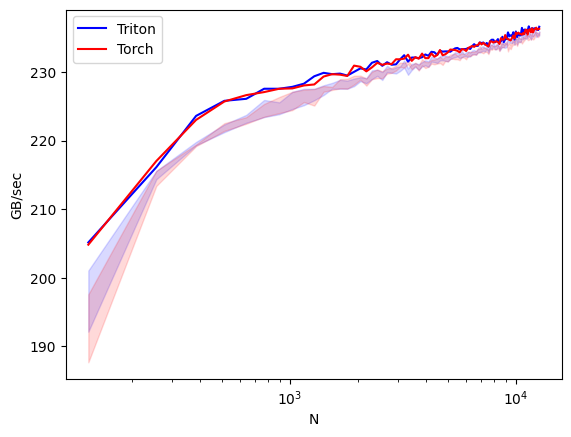

relu-performance:
          N      Triton       Torch
0     128.0  205.120508  204.800005
1     256.0  216.112112  217.006622
2     384.0  223.596042  223.012704
3     512.0  225.791560  225.694361
4     640.0  226.087560  226.623104
5     768.0  227.555555  227.069350
6     896.0  227.555557  227.555557
7    1024.0  227.832429  227.604953
8    1152.0  228.293195  228.035027
9    1280.0  229.375419  228.181471
10   1408.0  229.877559  229.336382
11   1536.0  229.682243  229.682243
12   1664.0  229.764829  229.610021
13   1792.0  229.476396  229.419016
14   1920.0  230.022178  230.929974
15   2048.0  230.527203  230.760556
16   2176.0  230.375251  230.092158
17   2304.0  231.348894  230.672578
18   2432.0  231.602890  231.333977
19   2560.0  230.902844  231.050390
20   2688.0  231.424102  231.225801
21   2816.0  231.056410  231.149022
22   2944.0  231.116149  231.857385
23   3072.0  231.849058  231.849058
24   3200.0  232.453212  231.948897
25   3328.0  231.513038  232.524020
26   3456.

In [7]:
benchmark.run(print_data=True, show_plots=True)